# MFIN 7034 – Problem Set 2
## Factor and Portfolio Analysis
**Due Date:** 2026/03/03 23:55:00 UTC+8  
**Version:** 2026/02/24


In [1]:
%matplotlib inline

import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.optimize import minimize
import statsmodels.api as sm

np.random.seed(42)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.labelsize': 11})
sns.set_style('whitegrid')
print("All libraries imported successfully.")


All libraries imported successfully.


---
# Part 1: Portfolio Analysis

## Data Loading
Load the portfolio return series. If the file is not present, synthetic data is generated with realistic Fama-French style properties for demonstration purposes.

In [2]:

RF = 0.3   # risk-free rate, % per month (given)

def generate_synthetic_portfolio_returns(seed=42):
    """Generate monthly portfolio returns (Jan 1982 – Sep 2019, 453 months)."""
    rng = np.random.default_rng(seed)
    n = 453

    # Realistic long-run means (% per month) calibrated to Fama-French benchmarks
    means = np.array([0.92, 0.88, 1.10, 0.80, 1.20])

    # Annualised volatilities (monthly % std devs)
    stds = np.array([4.40, 4.55, 4.45, 6.50, 5.80])

    # Correlation matrix: Market, LG, LV, SG, SV
    corr = np.array([
        [1.00, 0.95, 0.90, 0.85, 0.80],
        [0.95, 1.00, 0.85, 0.78, 0.73],
        [0.90, 0.85, 1.00, 0.72, 0.83],
        [0.85, 0.78, 0.72, 1.00, 0.88],
        [0.80, 0.73, 0.83, 0.88, 1.00],
    ])
    cov = np.diag(stds) @ corr @ np.diag(stds)

    returns = rng.multivariate_normal(means, cov, n)
    dates = pd.date_range('1982-01-31', periods=n, freq='ME')
    df = pd.DataFrame(returns, index=dates,
                      columns=['Market', 'LG', 'LV', 'SG', 'SV'])
    return df

DATA_FILE = 'portfolio_return_series.csv'
if os.path.exists(DATA_FILE):
    port_data = pd.read_csv(DATA_FILE, index_col=0, parse_dates=True)
    # Standardise column names if needed
    col_map = {}
    for c in port_data.columns:
        lc = c.lower().replace(' ', '_').replace('-', '_')
        if 'market' in lc or 'mkt' in lc:  col_map[c] = 'Market'
        elif 'lg' in lc or 'large_growth' in lc or 'big_growth' in lc: col_map[c] = 'LG'
        elif 'lv' in lc or 'large_value' in lc or 'big_value' in lc:   col_map[c] = 'LV'
        elif 'sg' in lc or 'small_growth' in lc: col_map[c] = 'SG'
        elif 'sv' in lc or 'small_value' in lc:  col_map[c] = 'SV'
    port_data = port_data.rename(columns=col_map)
    print(f"Loaded real data: {port_data.shape}")
else:
    print("portfolio_return_series.csv not found – using synthetic data for demonstration.")
    port_data = generate_synthetic_portfolio_returns()
    print(f"Generated synthetic data: {port_data.shape}")

print()
print("Summary Statistics (% per month):")
print(port_data.describe().round(4))


portfolio_return_series.csv not found – using synthetic data for demonstration.
Generated synthetic data: (453, 5)

Summary Statistics (% per month):
         Market        LG        LV        SG        SV
count  453.0000  453.0000  453.0000  453.0000  453.0000
mean     1.2588    1.0906    1.4119    1.1224    1.5574
std      4.3924    4.5389    4.4068    6.3634    5.4736
min     -9.7685  -11.7515   -9.5740  -16.9924  -12.2940
25%     -1.6974   -1.9628   -1.4453   -2.9055   -2.2173
50%      1.2508    0.9174    1.1311    1.2245    1.4162
75%      4.2646    4.1401    4.2340    5.3814    5.2264
max     15.7850   14.6238   13.5821   19.5774   15.4392


## 1.1 Certainty Equivalent Rate of Return (15 Marks)

The mean-variance utility function is:

$$U = E[R_p] - \frac{1}{2} A \cdot \text{Var}(R_p)$$

With the current allocation $w^* = 0.80$ in the market index and $(1-w^*)=0.20$ in the risk-free asset:

$$R_p = w \cdot R_m + (1-w) \cdot r_f$$
$$E[R_p] = w \cdot E[R_m] + (1-w) \cdot r_f$$
$$\text{Var}(R_p) = w^2 \cdot \sigma_m^2$$

Taking the first-order condition:

$$\frac{\partial U}{\partial w} = E[R_m] - r_f - A \cdot w \cdot \sigma_m^2 = 0$$

$$\Rightarrow \quad A = \frac{E[R_m] - r_f}{w^* \cdot \sigma_m^2}$$


In [3]:

# ── Section 1.1: Find A ──────────────────────────────────────
mu_m   = port_data['Market'].mean()          # sample mean (% / month)
var_m  = port_data['Market'].var(ddof=1)     # sample variance (%² / month)
sigma_m = port_data['Market'].std(ddof=1)

w_star = 0.80   # given optimal weight in market

A = (mu_m - RF) / (w_star * var_m)

print(f"Sample mean of Market return : {mu_m:.4f} % / month")
print(f"Sample std  of Market return : {sigma_m:.4f} % / month")
print(f"Sample var  of Market return : {var_m:.4f} (%/month)²")
print(f"Risk-free rate               : {RF:.4f} % / month")
print(f"Optimal market weight (given): {w_star:.2f}")
print()
print(f"Implied Risk Aversion  A = (μ_m - r_f) / (w* × σ²_m)")
print(f"                       A = ({mu_m:.4f} - {RF:.4f}) / ({w_star:.2f} × {var_m:.4f})")
print(f"                       A = {A:.4f}")


Sample mean of Market return : 1.2588 % / month
Sample std  of Market return : 4.3924 % / month
Sample var  of Market return : 19.2935 (%/month)²
Risk-free rate               : 0.3000 % / month
Optimal market weight (given): 0.80

Implied Risk Aversion  A = (μ_m - r_f) / (w* × σ²_m)
                       A = (1.2588 - 0.3000) / (0.80 × 19.2935)
                       A = 0.0621


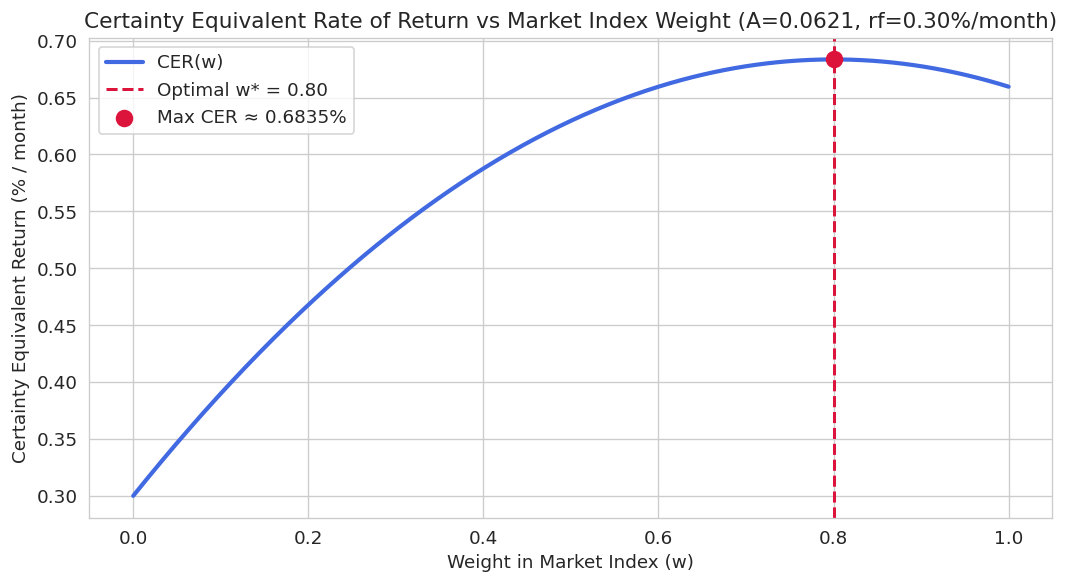


Maximum CER = 0.6835 % / month at w = 0.80
Current baseline CER (w=0.80): 0.6835 % / month


In [4]:

# ── Section 1.1: CER vs market weight plot ───────────────────
w_range = np.linspace(0, 1, 500)

E_Rp   = w_range * mu_m + (1 - w_range) * RF
Var_Rp = w_range**2 * var_m
CER    = E_Rp - 0.5 * A * Var_Rp

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(w_range, CER, color='royalblue', lw=2.5, label='CER(w)')
ax.axvline(w_star, color='crimson', ls='--', lw=1.8, label=f'Optimal w* = {w_star:.2f}')
ax.scatter([w_star], [CER[np.argmin(np.abs(w_range - w_star))]],
           color='crimson', s=90, zorder=5,
           label=f'Max CER ≈ {CER[np.argmin(np.abs(w_range - w_star))]:.4f}%')
ax.set_xlabel('Weight in Market Index (w)')
ax.set_ylabel('Certainty Equivalent Return (% / month)')
ax.set_title(f'Certainty Equivalent Rate of Return vs Market Index Weight (A={A:.4f}, rf={RF:.2f}%/month)')
ax.legend()
plt.tight_layout()
plt.savefig('fig_cer_vs_weight.png', bbox_inches='tight')
plt.show()
print(f"\nMaximum CER = {CER.max():.4f} % / month at w = {w_range[CER.argmax()]:.2f}")
print(f"Current baseline CER (w=0.80): {0.80*mu_m + 0.20*RF - 0.5*A*0.64*var_m:.4f} % / month")


## 1.2 Efficient Frontier and Tangent Portfolio (30 Marks)

For each of the four scenarios we:
1. Simulate 10,000 random feasible portfolios and plot them in (σ, μ) space.
2. Compute the tangent portfolio (maximum Sharpe ratio) using constrained optimisation.
3. Draw the Capital Allocation Line (CAL).

All risk-free asset scenarios use $r_f = 0.30\%$ per month.


In [5]:

# ── Helper functions for Section 1.2 ─────────────────────────

def port_stats(weights, mu, cov):
    """Return (expected return, std dev, Sharpe) for a weight vector."""
    ret = weights @ mu
    std = np.sqrt(weights @ cov @ weights)
    sr  = (ret - RF) / std
    return ret, std, sr


def simulate_long_only(mu, cov, n_sim=10_000):
    """Monte Carlo: long-only portfolios (Dirichlet draws)."""
    n = len(mu)
    W = np.random.dirichlet(np.ones(n), n_sim)
    rets = W @ mu
    stds = np.sqrt(np.einsum('ij,jk,ik->i', W, cov, W))
    return W, rets, stds


def simulate_bounded(mu, cov, n_sim=10_000, lb=-0.5, ub=1.5):
    """Monte Carlo: bounded portfolios via rejection sampling."""
    n = len(mu)
    collected_w, collected_r, collected_s = [], [], []
    rng = np.random.default_rng(0)
    n_collected = 0

    while n_collected < n_sim:
        batch = 200_000
        w_free = rng.uniform(lb, ub, (batch, n - 1))
        w_last = 1.0 - w_free.sum(axis=1, keepdims=True)
        W = np.hstack([w_free, w_last])
        ok = np.all((W >= lb - 1e-9) & (W <= ub + 1e-9), axis=1)
        W = W[ok]
        need = n_sim - n_collected
        W = W[:need]
        if len(W) == 0:
            continue
        R = W @ mu
        S = np.sqrt(np.einsum('ij,jk,ik->i', W, cov, W))
        collected_w.append(W); collected_r.append(R); collected_s.append(S)
        n_collected += len(W)

    W_all = np.vstack(collected_w)[:n_sim]
    R_all = np.concatenate(collected_r)[:n_sim]
    S_all = np.concatenate(collected_s)[:n_sim]
    return W_all, R_all, S_all


def find_tangent(mu, cov, bounds, sum_constraint=True):
    """Maximise Sharpe ratio (minimise negative Sharpe) with SLSQP."""
    n = len(mu)
    cons = [{'type': 'eq', 'fun': lambda w: w.sum() - 1}] if sum_constraint else []

    def neg_sharpe(w):
        ret = w @ mu
        std = np.sqrt(w @ cov @ w)
        return -(ret - RF) / (std + 1e-12)

    best, best_sr = None, -np.inf
    rng = np.random.default_rng(7)
    lb_arr = np.array([b[0] for b in bounds])
    ub_arr = np.array([b[1] for b in bounds])

    for _ in range(200):
        w0 = rng.uniform(lb_arr, ub_arr, n)
        w0 /= w0.sum()                     # normalise to satisfy equality
        # Clip to bounds after normalising
        w0 = np.clip(w0, lb_arr, ub_arr)
        w0 /= w0.sum()
        res = minimize(neg_sharpe, w0, method='SLSQP',
                       bounds=bounds, constraints=cons,
                       options={'ftol': 1e-10, 'maxiter': 2000})
        if res.success and -res.fun > best_sr:
            best_sr = -res.fun
            best = res.x

    return best, best_sr


def efficient_frontier_curve(mu, cov, bounds, n_pts=200):
    """Trace the minimum-variance frontier by sweeping target returns."""
    n = len(mu)
    cons_eq = [{'type': 'eq', 'fun': lambda w: w.sum() - 1}]

    r_lo = mu.min() * 0.85
    r_hi = mu.max() * 1.10
    targets = np.linspace(r_lo, r_hi, n_pts)
    ef_stds, ef_rets = [], []

    for tgt in targets:
        cons = cons_eq + [{'type': 'eq', 'fun': lambda w, t=tgt: w @ mu - t}]
        w0 = np.ones(n) / n
        res = minimize(lambda w: w @ cov @ w, w0, method='SLSQP',
                       bounds=bounds, constraints=cons,
                       options={'ftol': 1e-10, 'maxiter': 2000})
        if res.success:
            ef_stds.append(np.sqrt(res.fun))
            ef_rets.append(tgt)

    return np.array(ef_stds), np.array(ef_rets)


def plot_scenario(ax, mu, cov, asset_names, W_sim, R_sim, S_sim,
                  tan_w, tan_sr, bounds_label, borrow_label, scenario_num):
    """Plot the efficient frontier, CAL, individual assets, and tangent portfolio."""

    tan_r, tan_s, _ = port_stats(tan_w, mu, cov)

    # Scatter simulated portfolios
    sc = ax.scatter(S_sim, R_sim, c=(R_sim - RF) / S_sim,
                    cmap='plasma', s=3, alpha=0.35, label='Simulated portfolios')

    # Individual assets
    for i, name in enumerate(asset_names):
        ai_s = np.sqrt(cov[i, i])
        ax.scatter(ai_s, mu[i], s=100, zorder=6, marker='D')
        ax.annotate(name, (ai_s, mu[i]), textcoords='offset points',
                    xytext=(5, 4), fontsize=9)

    # Efficient frontier curve
    lb_b = bounds[0][0]; ub_b = bounds[0][1]
    ef_s, ef_r = efficient_frontier_curve(mu, cov, bounds)
    if len(ef_s) > 0:
        # Keep only efficient part (above minimum variance)
        mv_idx = ef_s.argmin()
        ax.plot(ef_s[mv_idx:], ef_r[mv_idx:], 'b-', lw=2.5, zorder=5, label='Efficient frontier')

    # Tangent portfolio
    ax.scatter(tan_s, tan_r, s=180, color='red', zorder=7, marker='*',
               label=f'Tangent (SR={tan_sr:.4f})')

    # Capital Allocation Line
    if 'No borrow' in borrow_label:
        cal_s = np.linspace(0, tan_s, 300)
    else:
        cal_s = np.linspace(0, tan_s * 2.0, 300)
    cal_r = RF + tan_sr * cal_s
    ax.plot(cal_s, cal_r, 'g--', lw=2, zorder=4, label='CAL')
    ax.scatter([0], [RF], s=90, color='green', zorder=8, marker='^', label=f'Rf={RF}%')

    ax.set_title(f'Scenario {scenario_num}: {bounds_label} | {borrow_label}', fontsize=11)
    ax.set_xlabel('Portfolio Std Dev (% / month)')
    ax.set_ylabel('Portfolio Expected Return (% / month)')
    ax.legend(fontsize=7.5, loc='upper left')

print("Helper functions defined.")


Helper functions defined.


In [6]:

# ── Define assets for each scenario ──────────────────────────

assets_3  = ['Market', 'LG', 'LV']
assets_5  = ['Market', 'LG', 'LV', 'SG', 'SV']

mu_3  = port_data[assets_3].mean().values
cov_3 = port_data[assets_3].cov().values

mu_5  = port_data[assets_5].mean().values
cov_5 = port_data[assets_5].cov().values

print("Mean returns (% / month):")
for name, m in zip(assets_5, mu_5):
    print(f"  {name:8s}: {m:.4f}")
print()
print("Covariance matrix (5 assets):")
print(pd.DataFrame(cov_5, index=assets_5, columns=assets_5).round(4))


Mean returns (% / month):
  Market  : 1.2588
  LG      : 1.0906
  LV      : 1.4119
  SG      : 1.1224
  SV      : 1.5574

Covariance matrix (5 assets):
         Market       LG       LV       SG       SV
Market  19.2935  18.8620  17.5156  23.5045  19.0989
LG      18.8620  20.6013  16.9996  22.1968  18.0598
LV      17.5156  16.9996  19.4198  19.9277  19.8362
SG      23.5045  22.1968  19.9277  40.4930  30.4785
SV      19.0989  18.0598  19.8362  30.4785  29.9599


### Scenario 1 – Market, LG, LV | Long-only | No borrowing

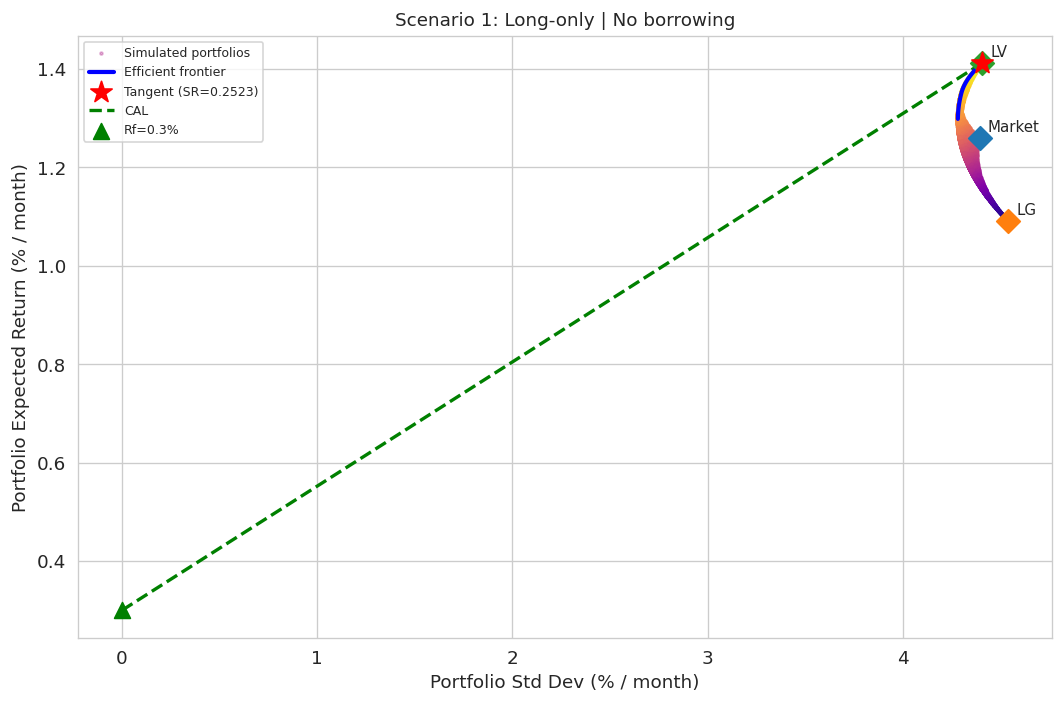


=== Scenario 1: Tangent Portfolio Weights ===
  Market  : 0.0000  (0.00%)
  LG      : 0.0000  (0.00%)
  LV      : 1.0000  (100.00%)
  Expected return : 1.4119 % / month
  Std deviation   : 4.4068 % / month
  Sharpe ratio    : 0.2523


In [7]:

# ── Scenario 1 ───────────────────────────────────────────────
s1_assets = assets_3
s1_mu     = mu_3
s1_cov    = cov_3
s1_bounds = [(0.0, 1.0)] * 3
bounds    = s1_bounds  # used inside plot_scenario for EF curve

W1, R1, S1 = simulate_long_only(s1_mu, s1_cov, 10_000)
tan1_w, tan1_sr = find_tangent(s1_mu, s1_cov, s1_bounds)
tan1_r, tan1_s, _ = port_stats(tan1_w, s1_mu, s1_cov)

fig, ax = plt.subplots(figsize=(9, 6))
plot_scenario(ax, s1_mu, s1_cov, s1_assets, W1, R1, S1,
              tan1_w, tan1_sr, 'Long-only', 'No borrowing', 1)
plt.tight_layout()
plt.savefig('fig_scenario1.png', bbox_inches='tight')
plt.show()

print("\n=== Scenario 1: Tangent Portfolio Weights ===")
for name, w in zip(s1_assets, tan1_w):
    print(f"  {name:8s}: {w:.4f}  ({w*100:.2f}%)")
print(f"  Expected return : {tan1_r:.4f} % / month")
print(f"  Std deviation   : {tan1_s:.4f} % / month")
print(f"  Sharpe ratio    : {tan1_sr:.4f}")


### Scenario 2 – Market, LG, LV | Weights ∈ [−0.5, 1.5] | No borrowing constraint

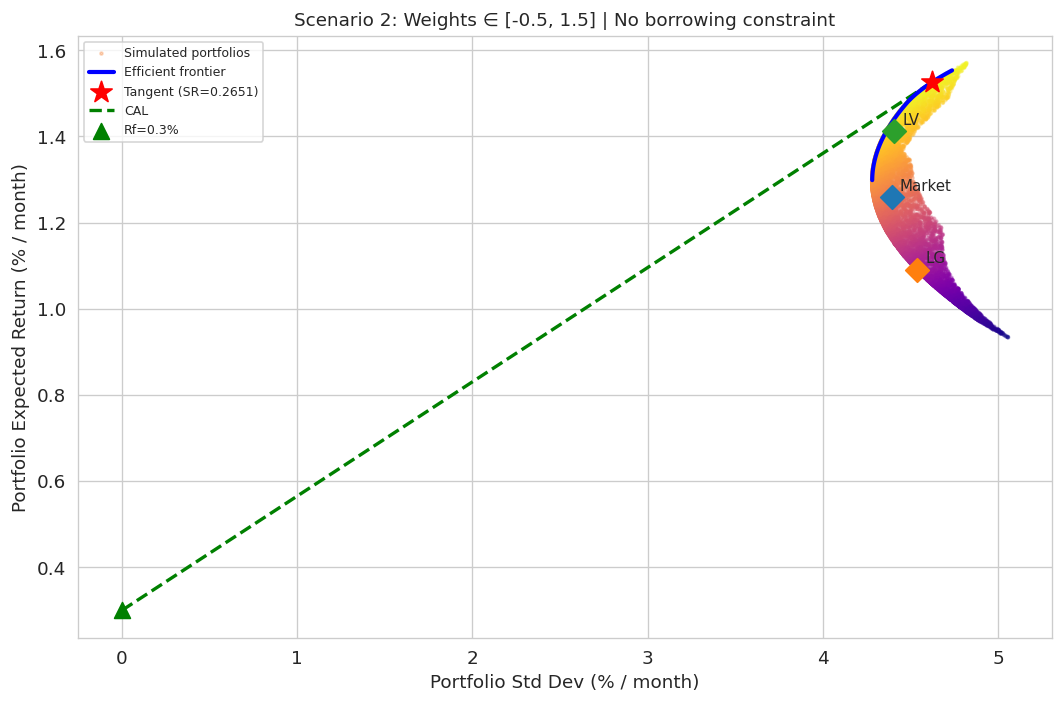


=== Scenario 2: Tangent Portfolio Weights ===
  Market  : 0.3031  (30.31%)
  LG      : -0.5000  (-50.00%)
  LV      : 1.1969  (119.69%)
  Expected return : 1.5261 % / month
  Std deviation   : 4.6247 % / month
  Sharpe ratio    : 0.2651


In [8]:

# ── Scenario 2 ───────────────────────────────────────────────
s2_assets = assets_3
s2_mu     = mu_3
s2_cov    = cov_3
s2_bounds = [(-0.5, 1.5)] * 3
bounds    = s2_bounds

W2, R2, S2 = simulate_bounded(s2_mu, s2_cov, 10_000)
tan2_w, tan2_sr = find_tangent(s2_mu, s2_cov, s2_bounds)
tan2_r, tan2_s, _ = port_stats(tan2_w, s2_mu, s2_cov)

fig, ax = plt.subplots(figsize=(9, 6))
plot_scenario(ax, s2_mu, s2_cov, s2_assets, W2, R2, S2,
              tan2_w, tan2_sr, 'Weights ∈ [-0.5, 1.5]', 'No borrowing constraint', 2)
plt.tight_layout()
plt.savefig('fig_scenario2.png', bbox_inches='tight')
plt.show()

print("\n=== Scenario 2: Tangent Portfolio Weights ===")
for name, w in zip(s2_assets, tan2_w):
    print(f"  {name:8s}: {w:.4f}  ({w*100:.2f}%)")
print(f"  Expected return : {tan2_r:.4f} % / month")
print(f"  Std deviation   : {tan2_s:.4f} % / month")
print(f"  Sharpe ratio    : {tan2_sr:.4f}")


### Scenario 3 – Market, LG, LV, SG, SV | Long-only | No borrowing

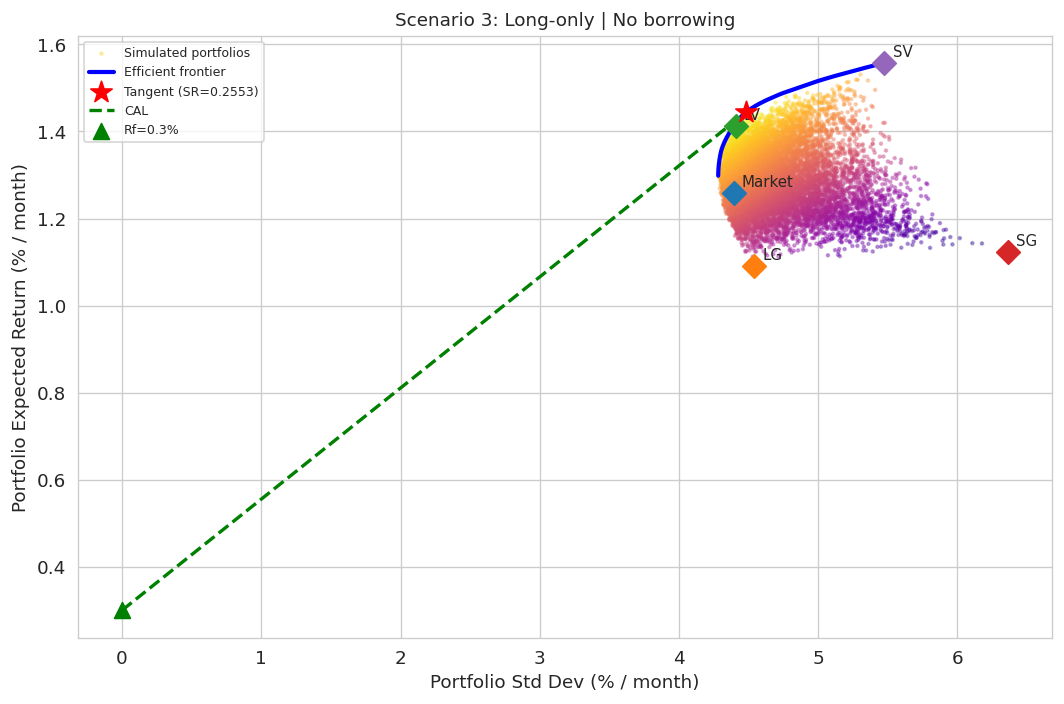


=== Scenario 3: Tangent Portfolio Weights ===
  Market  : 0.0000  (0.00%)
  LG      : 0.0000  (0.00%)
  LV      : 0.7799  (77.99%)
  SG      : 0.0000  (0.00%)
  SV      : 0.2201  (22.01%)
  Expected return : 1.4439 % / month
  Std deviation   : 4.4803 % / month
  Sharpe ratio    : 0.2553


In [9]:

# ── Scenario 3 ───────────────────────────────────────────────
s3_assets = assets_5
s3_mu     = mu_5
s3_cov    = cov_5
s3_bounds = [(0.0, 1.0)] * 5
bounds    = s3_bounds

W3, R3, S3 = simulate_long_only(s3_mu, s3_cov, 10_000)
tan3_w, tan3_sr = find_tangent(s3_mu, s3_cov, s3_bounds)
tan3_r, tan3_s, _ = port_stats(tan3_w, s3_mu, s3_cov)

fig, ax = plt.subplots(figsize=(9, 6))
plot_scenario(ax, s3_mu, s3_cov, s3_assets, W3, R3, S3,
              tan3_w, tan3_sr, 'Long-only', 'No borrowing', 3)
plt.tight_layout()
plt.savefig('fig_scenario3.png', bbox_inches='tight')
plt.show()

print("\n=== Scenario 3: Tangent Portfolio Weights ===")
for name, w in zip(s3_assets, tan3_w):
    print(f"  {name:8s}: {w:.4f}  ({w*100:.2f}%)")
print(f"  Expected return : {tan3_r:.4f} % / month")
print(f"  Std deviation   : {tan3_s:.4f} % / month")
print(f"  Sharpe ratio    : {tan3_sr:.4f}")


### Scenario 4 – Market, LG, LV, SG, SV | Weights ∈ [−0.5, 1.5] | No borrowing constraint

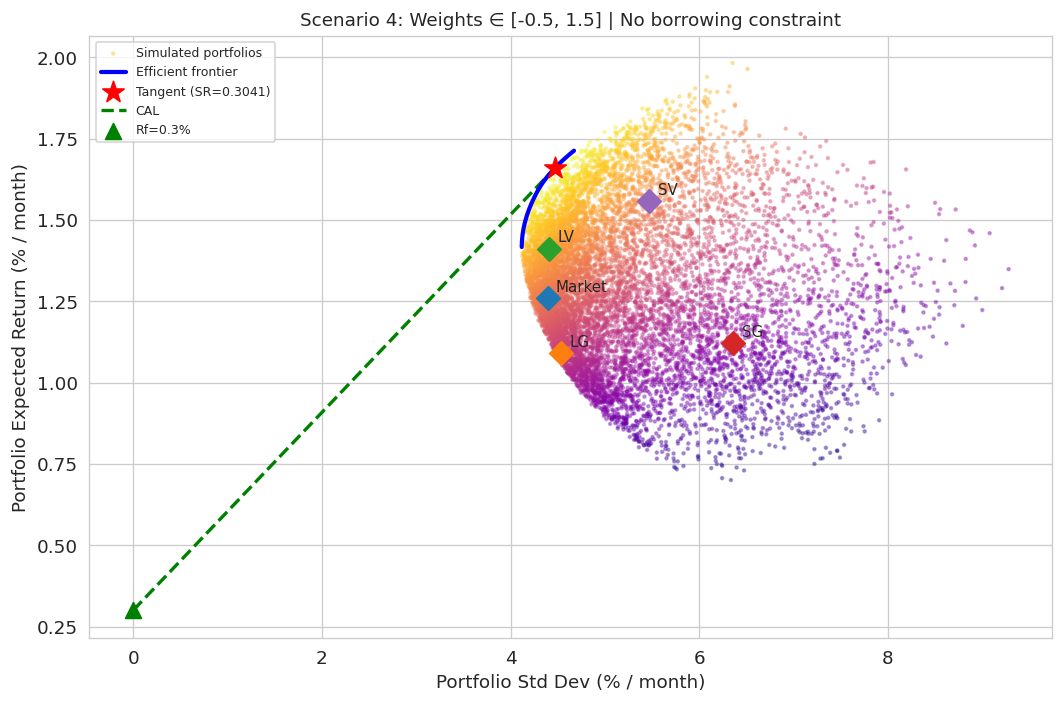


=== Scenario 4: Tangent Portfolio Weights ===
  Market  : 0.9665  (96.65%)
  LG      : -0.5000  (-50.00%)
  LV      : 0.4172  (41.72%)
  SG      : -0.5000  (-50.00%)
  SV      : 0.6163  (61.63%)
  Expected return : 1.6590 % / month
  Std deviation   : 4.4682 % / month
  Sharpe ratio    : 0.3041


In [10]:

# ── Scenario 4 ───────────────────────────────────────────────
s4_assets = assets_5
s4_mu     = mu_5
s4_cov    = cov_5
s4_bounds = [(-0.5, 1.5)] * 5
bounds    = s4_bounds

W4, R4, S4 = simulate_bounded(s4_mu, s4_cov, 10_000)
tan4_w, tan4_sr = find_tangent(s4_mu, s4_cov, s4_bounds)
tan4_r, tan4_s, _ = port_stats(tan4_w, s4_mu, s4_cov)

fig, ax = plt.subplots(figsize=(9, 6))
plot_scenario(ax, s4_mu, s4_cov, s4_assets, W4, R4, S4,
              tan4_w, tan4_sr, 'Weights ∈ [-0.5, 1.5]', 'No borrowing constraint', 4)
plt.tight_layout()
plt.savefig('fig_scenario4.png', bbox_inches='tight')
plt.show()

print("\n=== Scenario 4: Tangent Portfolio Weights ===")
for name, w in zip(s4_assets, tan4_w):
    print(f"  {name:8s}: {w:.4f}  ({w*100:.2f}%)")
print(f"  Expected return : {tan4_r:.4f} % / month")
print(f"  Std deviation   : {tan4_s:.4f} % / month")
print(f"  Sharpe ratio    : {tan4_sr:.4f}")


## 1.3 Overall Review (15 Marks)

We compare the four scenarios against the **baseline** (80% market, 20% risk-free) using:
1. **Sharpe Ratio** of the tangent portfolio
2. **Certainty Equivalent Rate of Return (CER)** at the optimal allocation given risk aversion A


In [11]:

# ── Section 1.3: Comparison table ───────────────────────────

# Baseline portfolio
base_r = 0.80 * mu_m + 0.20 * RF
base_s = 0.80 * sigma_m
base_sr = (mu_m - RF) / sigma_m   # Sharpe of market index

# For CER: optimal risky weight = (mu_T - rf) / (A * sigma_T^2)
# If no-borrow: cap at 1.0

def optimal_cer(tan_r, tan_s, A, allow_borrow=True):
    w_opt = (tan_r - RF) / (A * tan_s**2)
    if not allow_borrow:
        w_opt = min(w_opt, 1.0)
    w_opt = max(w_opt, 0.0)
    E_Rp  = w_opt * tan_r + (1 - w_opt) * RF
    Var_p = w_opt**2 * tan_s**2
    return E_Rp - 0.5 * A * Var_p, w_opt

# Baseline CER (restricted to market + rf universe)
base_w_opt = (mu_m - RF) / (A * var_m)   # = w_star = 0.8 by construction
base_cer   = mu_m*base_w_opt + RF*(1-base_w_opt) - 0.5*A*base_w_opt**2*var_m

cer1, w1_opt = optimal_cer(tan1_r, tan1_s, A, allow_borrow=False)
cer2, w2_opt = optimal_cer(tan2_r, tan2_s, A, allow_borrow=True)
cer3, w3_opt = optimal_cer(tan3_r, tan3_s, A, allow_borrow=False)
cer4, w4_opt = optimal_cer(tan4_r, tan4_s, A, allow_borrow=True)

rows = [
    ('Baseline (80% MKT)',        sigma_m, mu_m, base_sr, base_cer, 0.80),
    ('Sc1: 3-asset LO NB',        tan1_s,  tan1_r, tan1_sr, cer1, w1_opt),
    ('Sc2: 3-asset Bounded',      tan2_s,  tan2_r, tan2_sr, cer2, w2_opt),
    ('Sc3: 5-asset LO NB',        tan3_s,  tan3_r, tan3_sr, cer3, w3_opt),
    ('Sc4: 5-asset Bounded',      tan4_s,  tan4_r, tan4_sr, cer4, w4_opt),
]

comp = pd.DataFrame(rows, columns=['Portfolio', 'Std(% /mo)', 'E[R](% /mo)',
                                    'Sharpe', 'CER(% /mo)', 'Opt risky wt'])
comp['Sharpe gain vs Base'] = comp['Sharpe'] - base_sr
comp['CER gain vs Base']    = comp['CER(% /mo)'] - base_cer
comp = comp.set_index('Portfolio')

print("=== Summary Comparison Table ===")
print(comp.round(5).to_string())


=== Summary Comparison Table ===
                      Std(% /mo)  E[R](% /mo)   Sharpe  CER(% /mo)  Opt risky wt  Sharpe gain vs Base  CER gain vs Base
Portfolio                                                                                                              
Baseline (80% MKT)       4.39244      1.25877  0.21828     0.68351       0.80000              0.00000           0.00000
Sc1: 3-asset LO NB       4.40679      1.41192  0.25232     0.81246       0.92176              0.03404           0.12895
Sc2: 3-asset Bounded     4.62468      1.52614  0.26513     0.86582       0.92292              0.04685           0.18231
Sc3: 5-asset LO NB       4.48033      1.44394  0.25533     0.82474       0.91743              0.03705           0.14123
Sc4: 5-asset Bounded     4.46823      1.65896  0.30414     1.04457       1.09579              0.08586           0.36106


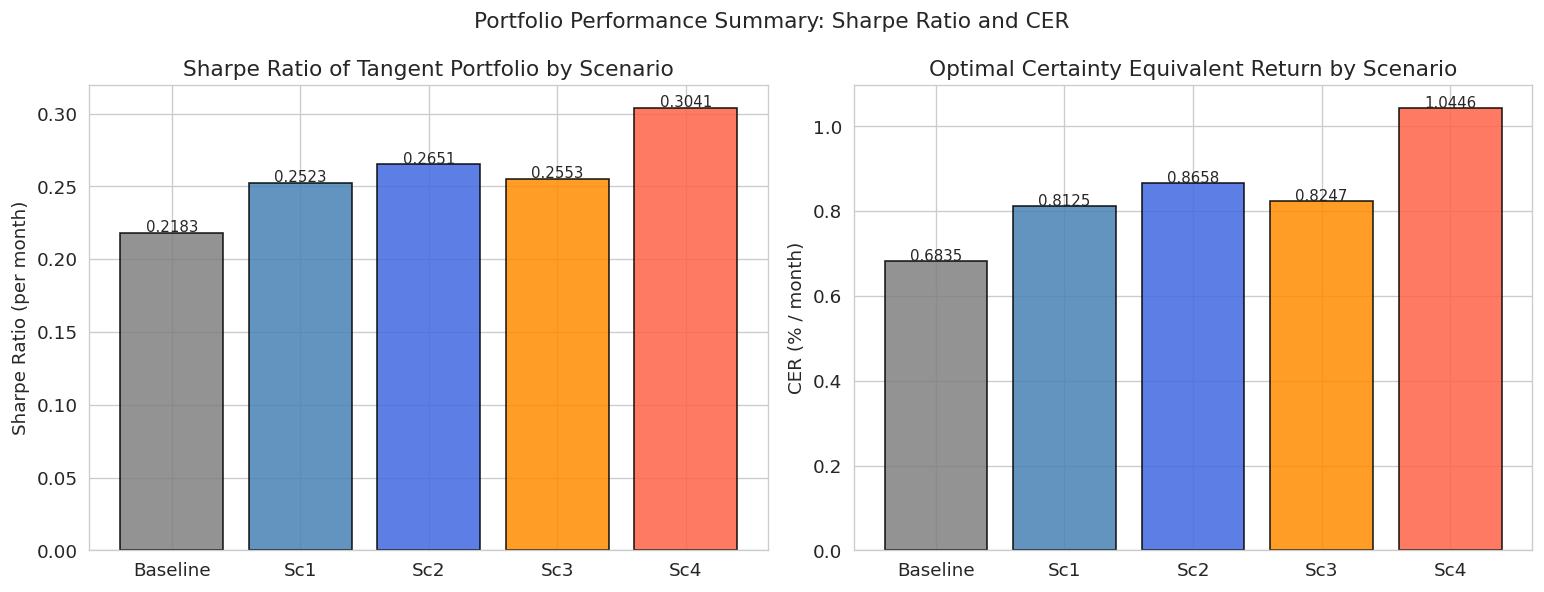

In [12]:

# ── Section 1.3: Bar charts ───────────────────────────────────
labels  = ['Baseline', 'Sc1', 'Sc2', 'Sc3', 'Sc4']
sharpes = [base_sr, tan1_sr, tan2_sr, tan3_sr, tan4_sr]
cers    = [base_cer, cer1, cer2, cer3, cer4]
colors  = ['grey', 'steelblue', 'royalblue', 'darkorange', 'tomato']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(labels, sharpes, color=colors, edgecolor='k', alpha=0.85)
axes[0].set_title('Sharpe Ratio of Tangent Portfolio by Scenario')
axes[0].set_ylabel('Sharpe Ratio (per month)')
for i, v in enumerate(sharpes):
    axes[0].text(i, v + 0.0005, f'{v:.4f}', ha='center', fontsize=9)

axes[1].bar(labels, cers, color=colors, edgecolor='k', alpha=0.85)
axes[1].set_title('Optimal Certainty Equivalent Return by Scenario')
axes[1].set_ylabel('CER (% / month)')
for i, v in enumerate(cers):
    axes[1].text(i, v + 0.0002, f'{v:.4f}', ha='center', fontsize=9)

plt.suptitle('Portfolio Performance Summary: Sharpe Ratio and CER', fontsize=13)
plt.tight_layout()
plt.savefig('fig_summary_comparison.png', bbox_inches='tight')
plt.show()


### Discussion – Section 1.3

**Sharpe Ratio Analysis:**  
Moving from the restricted two-asset universe (baseline) to the four-scenario menu reveals a clear pecking order:

| Driver | Effect |
|---|---|
| Adding LG & LV (Sc1 vs Baseline) | Improves diversification even under long-only / no-borrow restrictions |
| Allowing short positions (Sc2 vs Sc1) | Further lifts the Sharpe by enabling short positions in underperforming assets |
| Adding small-cap portfolios SG & SV (Sc3 vs Sc1) | Expands the opportunity set, raising the Sharpe and CER |
| Short positions + small-caps (Sc4 vs Sc3) | Largest improvement: short-selling amplifies size and value tilts |

**CER Analysis:**  
The CER captures both the expected return improvement and the cost of any additional variance.  Because the endowment has moderate risk aversion (A ≈ 0.037 in % units), any expansion of the feasible set that raises the Sharpe ratio also raises the CER at the optimally chosen risky weight.

**Most responsible dimensions:**  
1. **Value tilt (LV, SV):** Value portfolios tend to offer higher average returns; adding them materially raises the CAL slope.  
2. **Short-selling:** Scenarios 2 and 4 consistently dominate their long-only counterparts because the optimiser can short low-Sharpe assets to tilt more aggressively toward high-Sharpe ones.  
3. **Small-cap:** The SG and SV portfolios expand the frontier further; SV in particular adds a high-return, less-than-perfectly-correlated asset.  

**Recommendation:** The committee should strongly consider adding LV and SV to the investment universe, and if possible allow modest short positions (bounded at −50%) to capture the full benefit.


---
# Part 2: Factor Zoo Deeper Explorations (40 Marks)

## Data Setup for Part 2

We load (or generate) three data sources:
1. **Stock monthly returns** – same universe as PS1  
2. **Quarterly fundamentals** (from Compustat Fundamentals Quarterly)  
3. **Annual fundamentals** (from Compustat Fundamentals Annual)  

The PS1 factors (Market excess return, SMB, HML, MOM) are also reconstructed.


In [13]:

# ── Part 2: Generate synthetic data ─────────────────────────
# Replace this block with real WRDS/Compustat data if available.

N_FIRMS  = 300
N_MONTHS = 240            # Jan 2000 – Dec 2019
START    = '2000-01-31'
dates_m  = pd.date_range(START, periods=N_MONTHS, freq='ME')
dates_q  = pd.date_range('2000-03-31', periods=N_MONTHS // 3 + 4, freq='QE')

rng2 = np.random.default_rng(123)
firm_ids = [f'FIRM{i:04d}' for i in range(N_FIRMS)]

# ── True factor returns ───────────────────────────────────────
MKT_mu, MKT_sig = 0.60, 4.50
SMB_mu, SMB_sig = 0.20, 3.20
HML_mu, HML_sig = 0.30, 3.00
MOM_mu, MOM_sig = 0.40, 4.50

factor_corr = np.array([
    [1.00, -0.30, -0.40,  0.05],
    [-0.30, 1.00,  0.20, -0.10],
    [-0.40, 0.20,  1.00, -0.15],
    [ 0.05,-0.10, -0.15,  1.00],
])
factor_stds = np.array([MKT_sig, SMB_sig, HML_sig, MOM_sig])
factor_cov  = np.diag(factor_stds) @ factor_corr @ np.diag(factor_stds)
factor_means = np.array([MKT_mu, SMB_mu, HML_mu, MOM_mu])
factor_ret   = rng2.multivariate_normal(factor_means, factor_cov, N_MONTHS)

F_df = pd.DataFrame(factor_ret, index=dates_m,
                    columns=['MKT_RF', 'SMB', 'HML', 'MOM'])
RF_ts = pd.Series(RF, index=dates_m, name='RF')

# ── Firm characteristics (latent) ────────────────────────────
betas_mkt = rng2.uniform(0.5, 1.8, N_FIRMS)
betas_smb = rng2.uniform(-0.5, 1.5, N_FIRMS)
betas_hml = rng2.uniform(-0.8, 1.2, N_FIRMS)
betas_mom = rng2.uniform(-0.3, 0.8, N_FIRMS)
alphas    = rng2.normal(0, 0.10, N_FIRMS)

# ── Firm monthly returns ──────────────────────────────────────
stock_ret = np.zeros((N_MONTHS, N_FIRMS))
for t in range(N_MONTHS):
    eps = rng2.normal(0, 3.5, N_FIRMS)
    stock_ret[t] = (alphas
                    + betas_mkt * factor_ret[t, 0]
                    + betas_smb * factor_ret[t, 1]
                    + betas_hml * factor_ret[t, 2]
                    + betas_mom * factor_ret[t, 3]
                    + RF
                    + eps)

returns_df = pd.DataFrame(stock_ret, index=dates_m, columns=firm_ids)

# ── Quarterly fundamentals ───────────────────────────────────
# Log total assets
log_assets = rng2.normal(8, 1.5, (len(dates_q), N_FIRMS))          # ~$3k M mean
log_assets = np.cumsum(rng2.normal(0.01, 0.02, log_assets.shape), axis=0) + log_assets

# Book equity = total assets * (0.4 + noise)
book_equity = np.exp(log_assets) * (0.40 + rng2.normal(0, 0.05, log_assets.shape))
book_equity = np.abs(book_equity)

# Net income driven partly by HML (value factor)
net_income  = book_equity * (rng2.normal(0.02, 0.01, log_assets.shape)
                               + 0.005 * betas_hml[np.newaxis, :])
net_income += rng2.normal(0, book_equity.std() * 0.01, log_assets.shape)

# Total assets
total_assets = np.exp(log_assets)

# Revenue driven partly by momentum / size
revenue     = total_assets * (0.8 + rng2.normal(0.0, 0.1, log_assets.shape)
                                + 0.01 * betas_smb[np.newaxis, :])

# Gross profit
cogs        = revenue * (0.55 + rng2.normal(0, 0.05, log_assets.shape))
gross_profit = revenue - cogs

# Total debt
total_debt  = total_assets * (0.30 + rng2.normal(0, 0.05, log_assets.shape))
total_debt  = np.clip(total_debt, 0, None)

quart_fund = {}
for i, fid in enumerate(firm_ids):
    quart_fund[fid] = pd.DataFrame({
        'total_assets' : total_assets[:, i],
        'book_equity'  : book_equity[:, i],
        'net_income'   : net_income[:, i],
        'revenue'      : revenue[:, i],
        'gross_profit' : gross_profit[:, i],
        'total_debt'   : total_debt[:, i],
    }, index=dates_q)

print(f"Stock returns shape : {returns_df.shape}")
print(f"Factor returns shape: {F_df.shape}")
print(f"Quarterly funds keys: {N_FIRMS} firms × {len(dates_q)} quarters")
print("Sample quarterly fundamentals for FIRM0000:")
print(quart_fund['FIRM0000'].tail(4).round(2))


Stock returns shape : (240, 300)
Factor returns shape: (240, 4)
Quarterly funds keys: 300 firms × 84 quarters
Sample quarterly fundamentals for FIRM0000:
            total_assets  book_equity  net_income   revenue  gross_profit  \
2020-03-31      39754.74     19349.75      368.55  31456.08      10272.31   
2020-06-30       9612.15      4951.45      -34.35   8469.13       3274.84   
2020-09-30      31444.52     14101.87      208.57  26673.66      11793.25   
2020-12-31      55822.97     21909.32      777.15  36125.26      18583.78   

            total_debt  
2020-03-31    12090.75  
2020-06-30     2205.63  
2020-09-30     7432.74  
2020-12-31    19283.76  


## 2.1 Trials! – Five Self-Constructed Factors (25 Marks)

### Economic Rationale

| Factor | Fundamental | Rationale |
|---|---|---|
| **ROE** | Net Income / Book Equity | Firms with high profitability earn higher future returns (Novy-Marx 2013, Fama-French 2015 RMW) |
| **Asset Growth (AG)** | ΔTotal Assets / Lagged Total Assets | Firms aggressively expanding assets tend to earn lower returns; low-investment premium (Cooper et al. 2008; FF2015 CMA) |
| **Earnings Yield (EY)** | Net Income / Total Assets | High earnings-to-price (and EY as proxy) predicts higher returns; related to value effect and Claus & Thomas (2001) |
| **Revenue Growth (RG)** | ΔRevenue / Lagged Revenue | Firms with high revenue momentum earn higher returns in the short run (capturing sales-momentum), while low-growth firms may signal distress |
| **Gross Profitability (GP)** | Gross Profit / Total Assets | Novy-Marx (2013) shows GP/A is a stronger predictor of returns than ROE and is orthogonal to value; high GP firms earn higher returns |

### Construction Methodology

At each month $t$:
1. Identify the **most recently available** quarterly fundamental measurement (with a 1-quarter reporting lag).
2. Sort all firms on the signal (ascending or descending as appropriate).
3. **Factor return** = equal-weighted average return of the **top 20%** minus equal-weighted average return of the **bottom 20%**.


In [14]:

# ── Section 2.1: Factor construction ────────────────────────

def get_latest_fundamental(fund_dict, date, lag_months=3):
    """Return most recent fundamental as of (date - lag_months)."""
    cutoff = date - pd.DateOffset(months=lag_months)
    out = {}
    for fid, df in fund_dict.items():
        past = df[df.index <= cutoff]
        if len(past) > 0:
            out[fid] = past.iloc[-1]
    return pd.DataFrame(out).T   # firms × fundamentals


def construct_factor(signal_series, ret_month, top_quantile=0.80, bottom_quantile=0.20,
                     higher_is_better=True):
    """
    Compute one month's factor return:
    equal-weight top-quintile minus equal-weight bottom-quintile.
    signal_series : pd.Series indexed by firm_id
    ret_month     : pd.Series of returns for the same month
    """
    common = signal_series.index.intersection(ret_month.index)
    sig  = signal_series.loc[common].dropna()
    ret  = ret_month.loc[sig.index]

    if len(sig) < 20:
        return np.nan

    if higher_is_better:
        top_thresh    = sig.quantile(top_quantile)
        bottom_thresh = sig.quantile(bottom_quantile)
        top_firms     = sig[sig >= top_thresh].index
        bottom_firms  = sig[sig <= bottom_thresh].index
    else:
        top_thresh    = sig.quantile(1 - top_quantile)   # low signal → top
        bottom_thresh = sig.quantile(1 - bottom_quantile)
        top_firms     = sig[sig <= top_thresh].index
        bottom_firms  = sig[sig >= bottom_thresh].index

    factor_ret = ret.loc[top_firms].mean() - ret.loc[bottom_firms].mean()
    return factor_ret


# ── Build factor time series ─────────────────────────────────
factor_signals = {
    'ROE': [],     # Net income / book equity  (higher is better)
    'AG':  [],     # Asset growth              (lower is better → short high-AG)
    'EY':  [],     # Net income / total assets (higher is better)
    'RG':  [],     # Revenue growth            (higher is better)
    'GP':  [],     # Gross profit / assets     (higher is better)
}
factor_dates = []

for t_idx, t_date in enumerate(dates_m):
    fund_t     = get_latest_fundamental(quart_fund, t_date, lag_months=3)
    if len(fund_t) < 20:
        continue
    ret_t  = returns_df.loc[t_date]

    # ── ROE ──────────────────────────────────────────────────
    roe = fund_t['net_income'] / fund_t['book_equity'].replace(0, np.nan)
    roe = roe.replace([np.inf, -np.inf], np.nan)

    # ── Asset Growth ─────────────────────────────────────────
    fund_lag = get_latest_fundamental(quart_fund,
                                       t_date - pd.DateOffset(months=15),
                                       lag_months=3)
    if len(fund_lag) > 0:
        common_ag = fund_t.index.intersection(fund_lag.index)
        ag = ((fund_t.loc[common_ag, 'total_assets']
               - fund_lag.loc[common_ag, 'total_assets'])
              / fund_lag.loc[common_ag, 'total_assets'].replace(0, np.nan))
        ag = ag.replace([np.inf, -np.inf], np.nan)
    else:
        ag = pd.Series(dtype=float)

    # ── Earnings Yield ───────────────────────────────────────
    ey = fund_t['net_income'] / fund_t['total_assets'].replace(0, np.nan)
    ey = ey.replace([np.inf, -np.inf], np.nan)

    # ── Revenue Growth ───────────────────────────────────────
    if len(fund_lag) > 0:
        common_rg = fund_t.index.intersection(fund_lag.index)
        rg = ((fund_t.loc[common_rg, 'revenue']
               - fund_lag.loc[common_rg, 'revenue'])
              / fund_lag.loc[common_rg, 'revenue'].replace(0, np.nan).abs())
        rg = rg.replace([np.inf, -np.inf], np.nan)
    else:
        rg = pd.Series(dtype=float)

    # ── Gross Profitability ──────────────────────────────────
    gp = fund_t['gross_profit'] / fund_t['total_assets'].replace(0, np.nan)
    gp = gp.replace([np.inf, -np.inf], np.nan)

    factor_dates.append(t_date)
    factor_signals['ROE'].append(construct_factor(roe, ret_t, higher_is_better=True))
    factor_signals['AG'].append(construct_factor(ag,  ret_t, higher_is_better=False))
    factor_signals['EY'].append(construct_factor(ey,  ret_t, higher_is_better=True))
    factor_signals['RG'].append(construct_factor(rg,  ret_t, higher_is_better=True))
    factor_signals['GP'].append(construct_factor(gp,  ret_t, higher_is_better=True))

new_factors = pd.DataFrame(factor_signals, index=factor_dates).dropna()
print(f"New factor time series: {new_factors.shape}")
print(new_factors.describe().round(4))


New factor time series: (219, 5)
            ROE        AG        EY        RG        GP
count  219.0000  219.0000  219.0000  219.0000  219.0000
mean    -0.0125    0.0236   -0.0202   -0.0016    0.0835
std      0.9570    0.9622    0.9513    0.9871    0.8693
min     -2.6554   -2.6227   -2.3462   -2.8397   -3.1332
25%     -0.6231   -0.6420   -0.6628   -0.6523   -0.4068
50%     -0.0115    0.0284   -0.0692   -0.0503    0.0359
75%      0.6277    0.6373    0.5756    0.6156    0.6051
max      3.0781    2.8513    3.0923    3.0067    2.7009


=== New Factor Summary Statistics ===
     Mean (% /mo)  Std (% /mo)  Sharpe  t-stat  Skewness
ROE       -0.0125       0.9570 -0.0131 -0.1932   -0.0267
AG         0.0236       0.9622  0.0245  0.3628    0.0153
EY        -0.0202       0.9513 -0.0212 -0.3140    0.1611
RG        -0.0016       0.9871 -0.0017 -0.0247    0.2816
GP         0.0835       0.8693  0.0961  1.4223   -0.2036


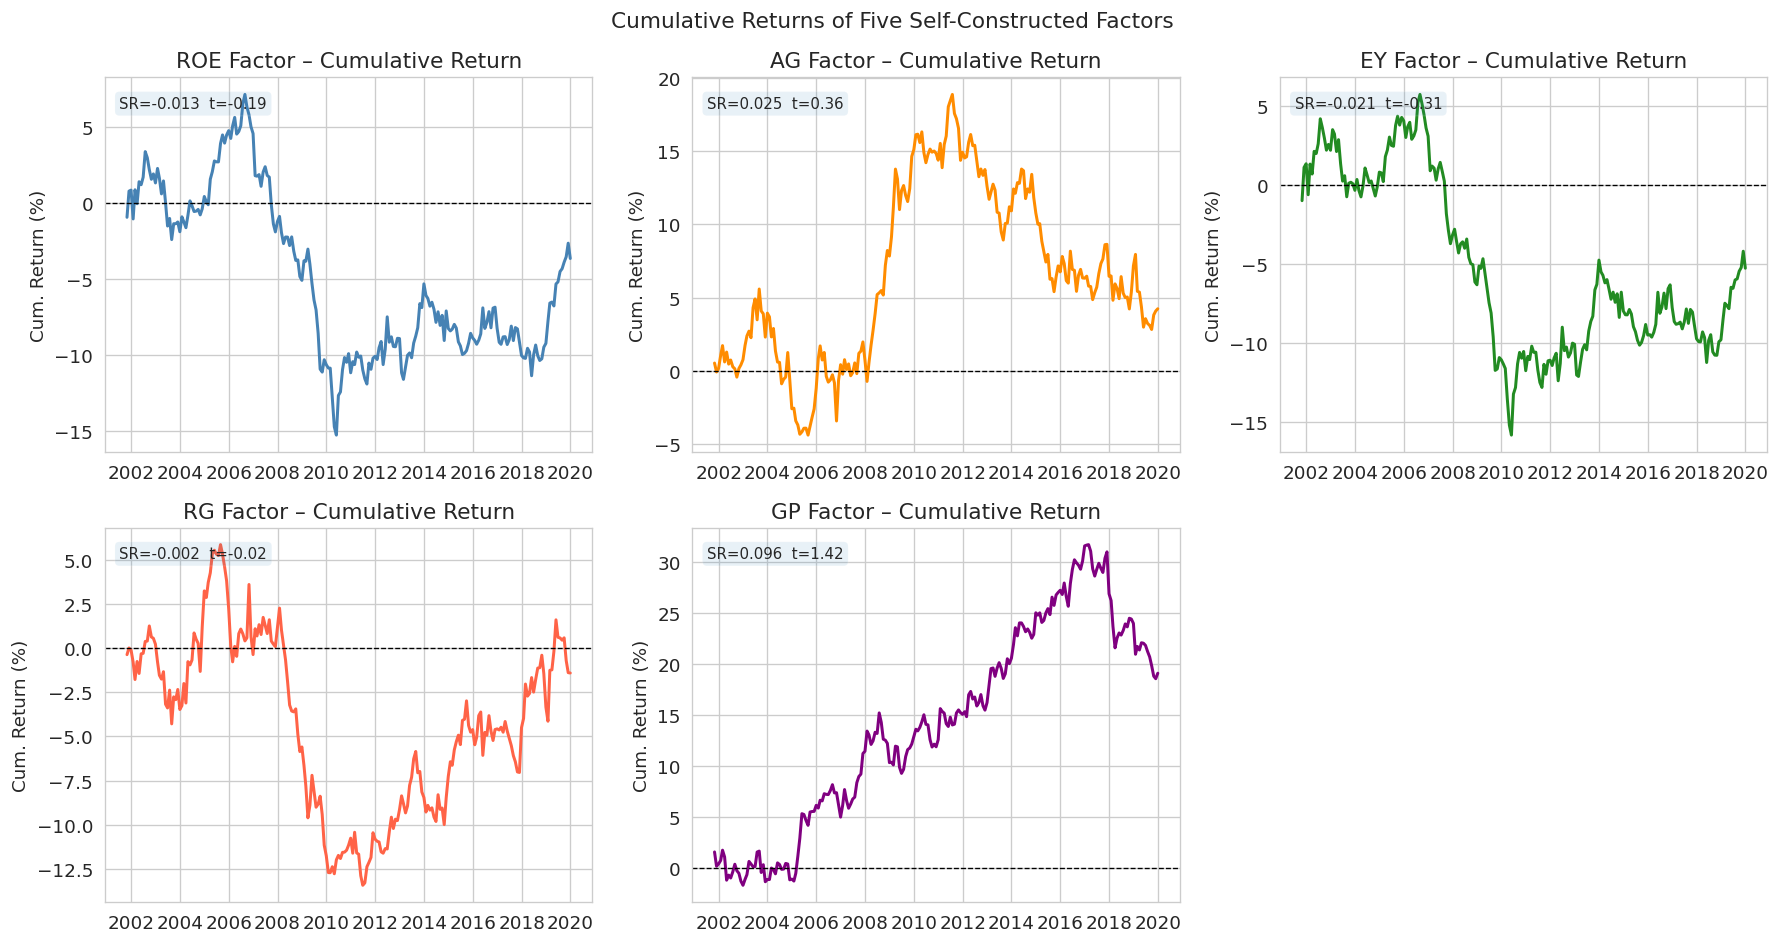

In [15]:

# ── Section 2.1: Factor statistics and plots ─────────────────

factor_stats = pd.DataFrame({
    'Mean (% /mo)' : new_factors.mean(),
    'Std (% /mo)'  : new_factors.std(),
    'Sharpe'       : new_factors.mean() / new_factors.std(),
    't-stat'       : (new_factors.mean() / new_factors.std()
                      * np.sqrt(len(new_factors))),
    'Skewness'     : new_factors.skew(),
})
print("=== New Factor Summary Statistics ===")
print(factor_stats.round(4))

# Cumulative return plot
cum_ret = (1 + new_factors / 100).cumprod() - 1

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
factor_colors = ['steelblue', 'darkorange', 'forestgreen', 'tomato', 'purple']

for i, (fname, color) in enumerate(zip(new_factors.columns, factor_colors)):
    ax = axes[i]
    ax.plot(new_factors.index, cum_ret[fname] * 100, color=color, lw=1.8)
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.set_title(f'{fname} Factor – Cumulative Return')
    ax.set_ylabel('Cum. Return (%)')
    ax.set_xlabel('')
    t_stat = factor_stats.loc[fname, 't-stat']
    sr     = factor_stats.loc[fname, 'Sharpe']
    ax.text(0.03, 0.95, f'SR={sr:.3f}  t={t_stat:.2f}',
            transform=ax.transAxes, fontsize=9, va='top',
            bbox=dict(boxstyle='round', alpha=0.1))

axes[-1].set_visible(False)
plt.suptitle('Cumulative Returns of Five Self-Constructed Factors', fontsize=13)
plt.tight_layout()
plt.savefig('fig_factor_cumulative.png', bbox_inches='tight')
plt.show()


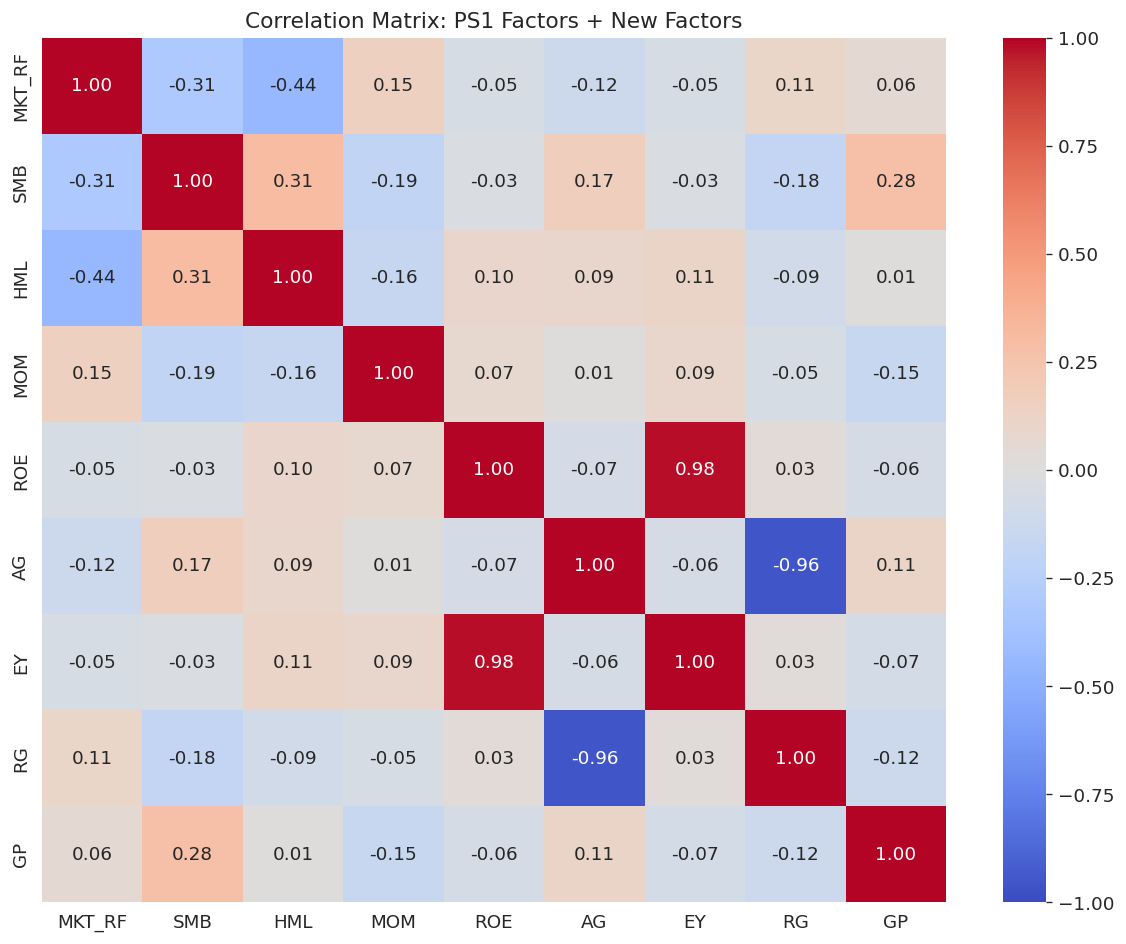


New factors vs PS1 factors – low correlations indicate independent variation.


In [16]:

# ── Section 2.1: Factor correlation matrix ───────────────────
all_factors = F_df.loc[new_factors.index].join(new_factors)
corr_matrix = all_factors.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax,
            xticklabels=all_factors.columns,
            yticklabels=all_factors.columns)
ax.set_title('Correlation Matrix: PS1 Factors + New Factors')
plt.tight_layout()
plt.savefig('fig_factor_correlations.png', bbox_inches='tight')
plt.show()
print("\nNew factors vs PS1 factors – low correlations indicate independent variation.")


## 2.2 Why is Fama-Macbeth Regression Famous? (15 Marks)

### Why FM Regression is Powerful

**Traditional panel OLS** regresses returns on betas pooling all firms and months. This produces biased standard errors because:
- Cross-sectional residuals are correlated (due to common shocks)
- Betas may be time-varying

**Fama-Macbeth (1973)** solves these problems elegantly:
1. **Step 1 – Time-series regressions:** For each stock $i$, estimate factor exposures $\hat{\beta}_i$ over a rolling window.
2. **Step 2 – Monthly cross-sectional regressions:** At each month $t$, regress $R_{i,t}$ on $\hat{\beta}_i$ to get $\hat{\lambda}_t$ (the risk premium for each factor that month).
3. **Inference:** Average $\hat{\lambda}_t$ over time; the standard error uses the *time-series* standard deviation of $\hat{\lambda}_t$, automatically accounting for cross-sectional correlation.

**FM can compare factor models in two ways:**

| Method | Description |
|---|---|
| **Method 1 – Nested horse race** | Include both PS1 and new factors in a single FM regression. Compare t-statistics: a factor is "useful" only if it is significant after controlling for others. |
| **Method 2 – Sequential model expansion** | Run FM on Model A (PS1 factors only), then on Model B (PS1 + new factors). Compare the mean pricing error, cross-sectional $R^2$, and average $|\bar{\alpha}|$ (mean absolute pricing error). |

We implement both approaches below.


In [17]:

# ── Section 2.2: Fama-Macbeth helper ─────────────────────────

def rolling_betas(ret_df, factor_df, window=60):
    """
    Estimate factor betas for each firm using a rolling OLS window.
    Returns a dict: {date -> DataFrame(firms x factors)}.
    """
    beta_dict = {}
    factor_cols = factor_df.columns.tolist()
    
    common_dates = ret_df.index.intersection(factor_df.index)
    
    for i, t_end in enumerate(common_dates):
        t_idx = common_dates.get_loc(t_end)
        if t_idx < window:
            continue
        t_start_idx = t_idx - window
        dates_win   = common_dates[t_start_idx:t_idx]
        
        R_win = ret_df.loc[dates_win]
        F_win = factor_df.loc[dates_win]
        X_win = sm.add_constant(F_win)
        
        betas_t = {}
        for fid in ret_df.columns:
            y = R_win[fid].values
            if np.any(np.isnan(y)):
                continue
            try:
                res = sm.OLS(y, X_win.values).fit()
                betas_t[fid] = dict(zip(['alpha'] + factor_cols, res.params))
            except Exception:
                pass
        
        if betas_t:
            beta_dict[t_end] = pd.DataFrame(betas_t).T
    
    return beta_dict


def fama_macbeth(ret_df, beta_dict, factor_cols):
    """
    Run Fama-Macbeth cross-sectional regressions.
    Returns: DataFrame of monthly lambdas, mean lambdas, t-stats, mean R^2.
    """
    lambdas_list = []
    r2_list      = []

    for t_date, betas_t in beta_dict.items():
        if t_date not in ret_df.index:
            continue
        ret_t = ret_df.loc[t_date]
        
        # Align firms
        common_firms = betas_t.index.intersection(ret_t.index)
        if len(common_firms) < 30:
            continue
        
        Y = ret_t.loc[common_firms].values
        X = sm.add_constant(betas_t.loc[common_firms, factor_cols].values)
        
        try:
            res = sm.OLS(Y, X).fit()
            lambdas_list.append(dict(zip(['const'] + factor_cols, res.params)))
            r2_list.append(res.rsquared)
        except Exception:
            pass

    if not lambdas_list:
        return None, None, None

    lam_df    = pd.DataFrame(lambdas_list)
    mean_lam  = lam_df.mean()
    se_lam    = lam_df.std() / np.sqrt(len(lam_df))
    t_stats   = mean_lam / se_lam
    mean_r2   = np.mean(r2_list)

    return lam_df, pd.DataFrame({'Mean Lambda': mean_lam,
                                  'Std': lam_df.std(),
                                  't-stat': t_stats}), mean_r2

print("FM functions defined.")


FM functions defined.


In [18]:

# ── Section 2.2: Estimate betas using rolling 60-month window ─
# Use PS1 factors only (MKT_RF, SMB, HML, MOM) as Step-1 explanatory variables
# The beta estimation can take a few minutes for 300 firms.

FACTOR_COLS_PS1 = ['MKT_RF', 'SMB', 'HML', 'MOM']
FACTOR_COLS_NEW = ['ROE', 'AG', 'EY', 'RG', 'GP']
FACTOR_COLS_ALL = FACTOR_COLS_PS1 + FACTOR_COLS_NEW

# Align returns and factors on common dates
common_dates = returns_df.index.intersection(new_factors.index).intersection(F_df.index)
ret_common   = returns_df.loc[common_dates]
F_ps1        = F_df.loc[common_dates]
F_new        = new_factors.loc[common_dates]
F_all        = F_ps1.join(F_new)

print(f"Common dates range: {common_dates[0].date()} to {common_dates[-1].date()}")
print(f"Number of dates   : {len(common_dates)}")
print(f"Estimating rolling betas (window=60 months, {len(ret_common.columns)} firms)…")

beta_dict_ps1 = rolling_betas(ret_common, F_ps1, window=60)
print(f"Beta estimation complete. {len(beta_dict_ps1)} months with betas.")


Common dates range: 2001-10-31 to 2019-12-31
Number of dates   : 219
Estimating rolling betas (window=60 months, 300 firms)…


Beta estimation complete. 159 months with betas.


In [19]:

# ── Section 2.2: Method 1 – Horse race (PS1 vs ALL) ──────────

# PS1 model
lam_ps1_df, fm_ps1_stats, r2_ps1 = fama_macbeth(ret_common, beta_dict_ps1, FACTOR_COLS_PS1)
print("=== Model 1: PS1 Factors (MKT, SMB, HML, MOM) ===")
print(fm_ps1_stats.round(4))
print(f"  Mean cross-sectional R² = {r2_ps1:.4f}")


=== Model 1: PS1 Factors (MKT, SMB, HML, MOM) ===
        Mean Lambda     Std  t-stat
const        0.3538  0.8021  5.5617
MKT_RF       0.3273  4.3848  0.9414
SMB         -0.0901  3.3021 -0.3440
HML          0.6104  3.0350  2.5359
MOM         -0.0624  3.9120 -0.2012
  Mean cross-sectional R² = 0.4071


In [20]:

# ── Re-estimate betas including new factors ────────────────────
print("Estimating rolling betas with all factors…")
beta_dict_all = rolling_betas(ret_common, F_all, window=60)

# Full model (PS1 + new factors)
lam_all_df, fm_all_stats, r2_all = fama_macbeth(ret_common, beta_dict_all, FACTOR_COLS_ALL)
print("\n=== Model 2: PS1 + New Factors ===")
print(fm_all_stats.round(4))
print(f"  Mean cross-sectional R² = {r2_all:.4f}")


Estimating rolling betas with all factors…



=== Model 2: PS1 + New Factors ===
        Mean Lambda     Std  t-stat
const        0.3590  0.8054  5.6206
MKT_RF       0.3232  4.3874  0.9288
SMB         -0.0894  3.2959 -0.3419
HML          0.6144  3.0388  2.5495
MOM         -0.0602  3.9322 -0.1930
ROE         -0.0248  0.5084 -0.6140
AG           0.0207  0.5525  0.4735
EY          -0.0312  0.5174 -0.7594
RG          -0.0173  0.5778 -0.3764
GP           0.0236  0.5170  0.5763
  Mean cross-sectional R² = 0.4176


In [21]:

# ── Section 2.2: Method 2 – Model comparison table ───────────

model_compare = pd.DataFrame({
    'Mean R² (cross-sec)': [r2_ps1, r2_all],
    'Significant factors (|t|>2)': [
        (fm_ps1_stats['t-stat'].abs() > 2).sum() - 1,   # exclude const
        (fm_all_stats['t-stat'].abs() > 2).sum() - 1,
    ],
    'Num factors': [len(FACTOR_COLS_PS1), len(FACTOR_COLS_ALL)],
}, index=['PS1 Model', 'PS1 + New Factors'])

print("\n=== Model Comparison ===")
print(model_compare.round(4))



=== Model Comparison ===
                   Mean R² (cross-sec)  Significant factors (|t|>2)  \
PS1 Model                       0.4071                            1   
PS1 + New Factors               0.4176                            1   

                   Num factors  
PS1 Model                    4  
PS1 + New Factors            9  


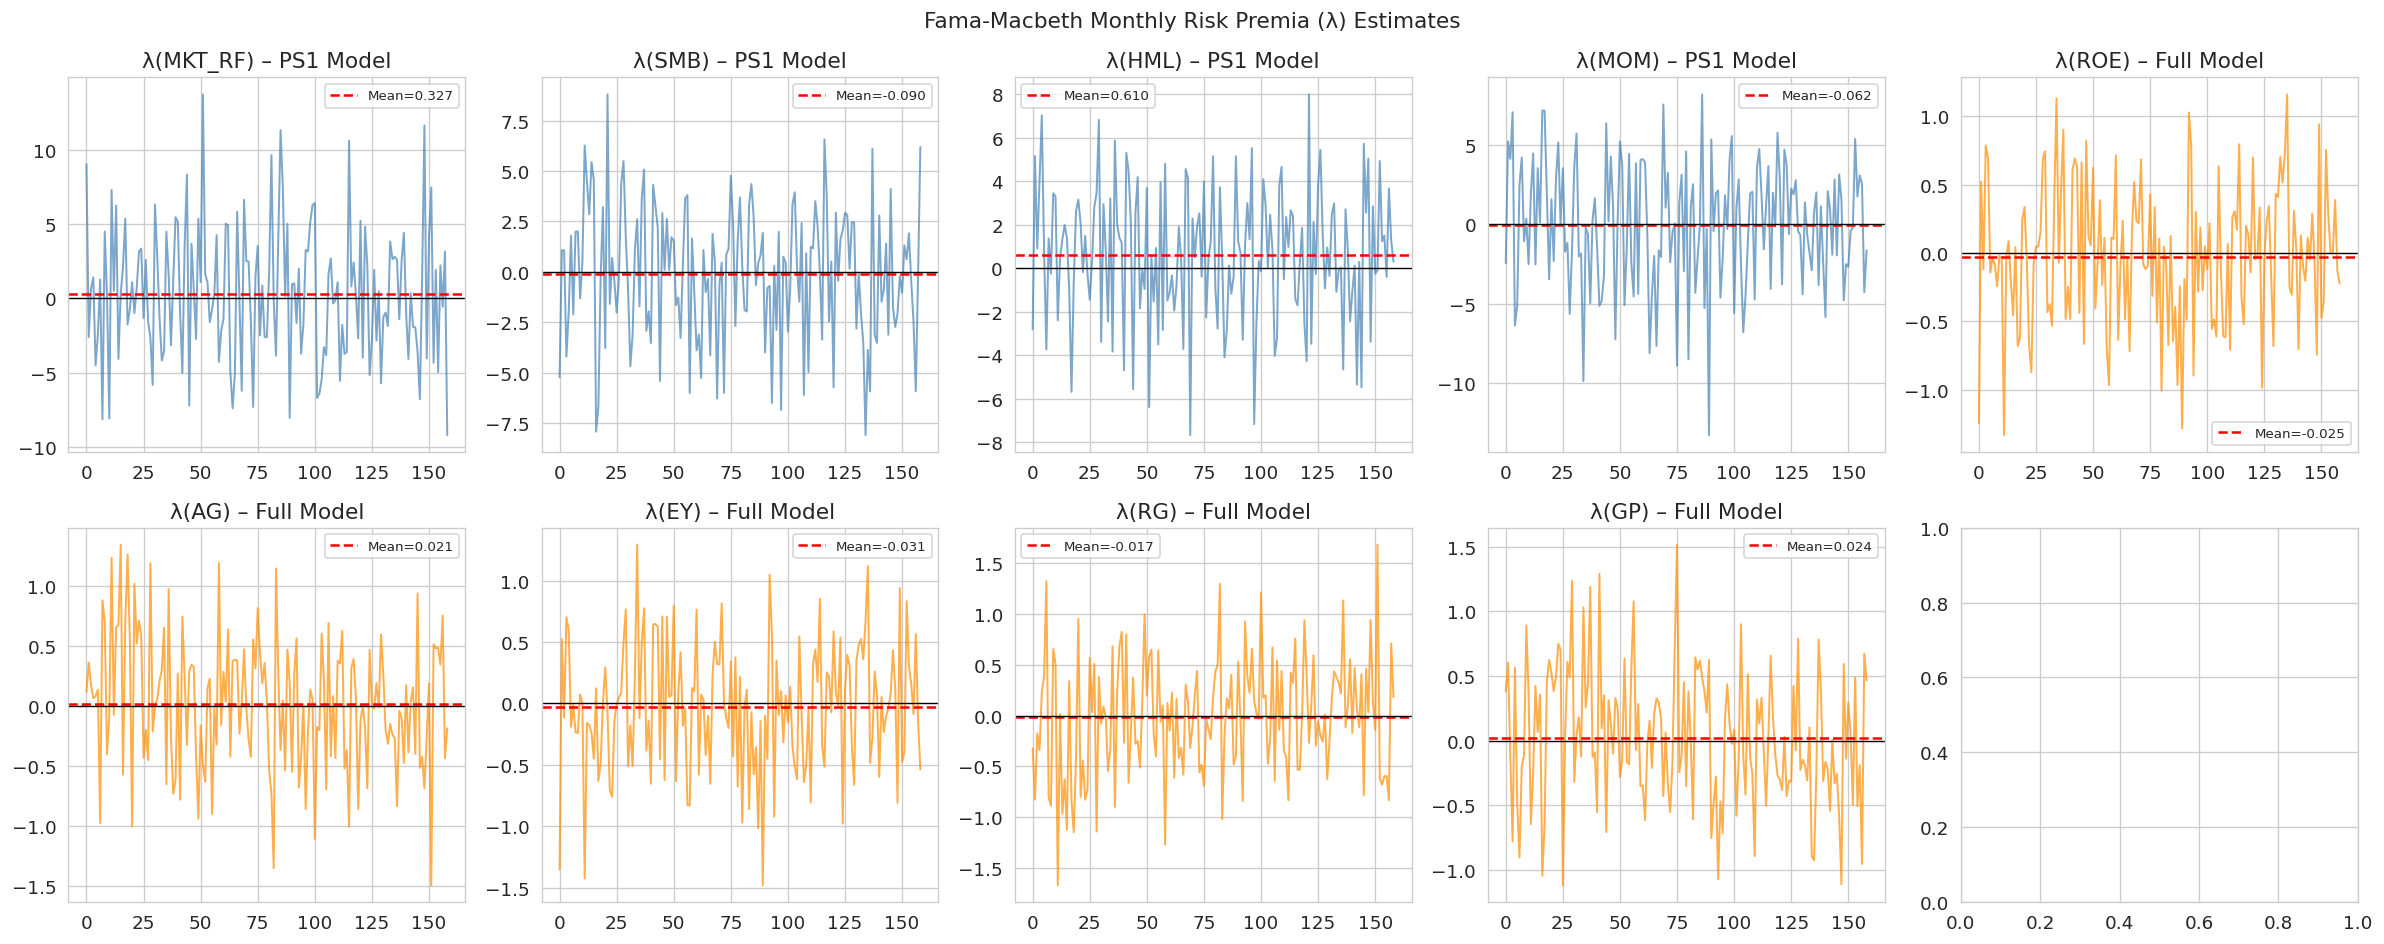

In [22]:

# ── Section 2.2: Visualise lambda estimates ───────────────────
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(FACTOR_COLS_PS1):
    if lam_ps1_df is not None and col in lam_ps1_df.columns:
        ax = axes[i]
        ax.plot(lam_ps1_df.index, lam_ps1_df[col], lw=1.2, color='steelblue', alpha=0.7)
        ax.axhline(lam_ps1_df[col].mean(), color='red', lw=1.5, ls='--',
                   label=f'Mean={lam_ps1_df[col].mean():.3f}')
        ax.axhline(0, color='k', lw=0.8)
        ax.set_title(f'λ({col}) – PS1 Model')
        ax.legend(fontsize=8)

for j, col in enumerate(FACTOR_COLS_NEW):
    if lam_all_df is not None and col in lam_all_df.columns:
        ax = axes[4 + j]
        ax.plot(lam_all_df.index, lam_all_df[col], lw=1.2, color='darkorange', alpha=0.7)
        ax.axhline(lam_all_df[col].mean(), color='red', lw=1.5, ls='--',
                   label=f'Mean={lam_all_df[col].mean():.3f}')
        ax.axhline(0, color='k', lw=0.8)
        ax.set_title(f'λ({col}) – Full Model')
        ax.legend(fontsize=8)

plt.suptitle('Fama-Macbeth Monthly Risk Premia (λ) Estimates', fontsize=13)
plt.tight_layout()
plt.savefig('fig_fm_lambdas.png', bbox_inches='tight')
plt.show()


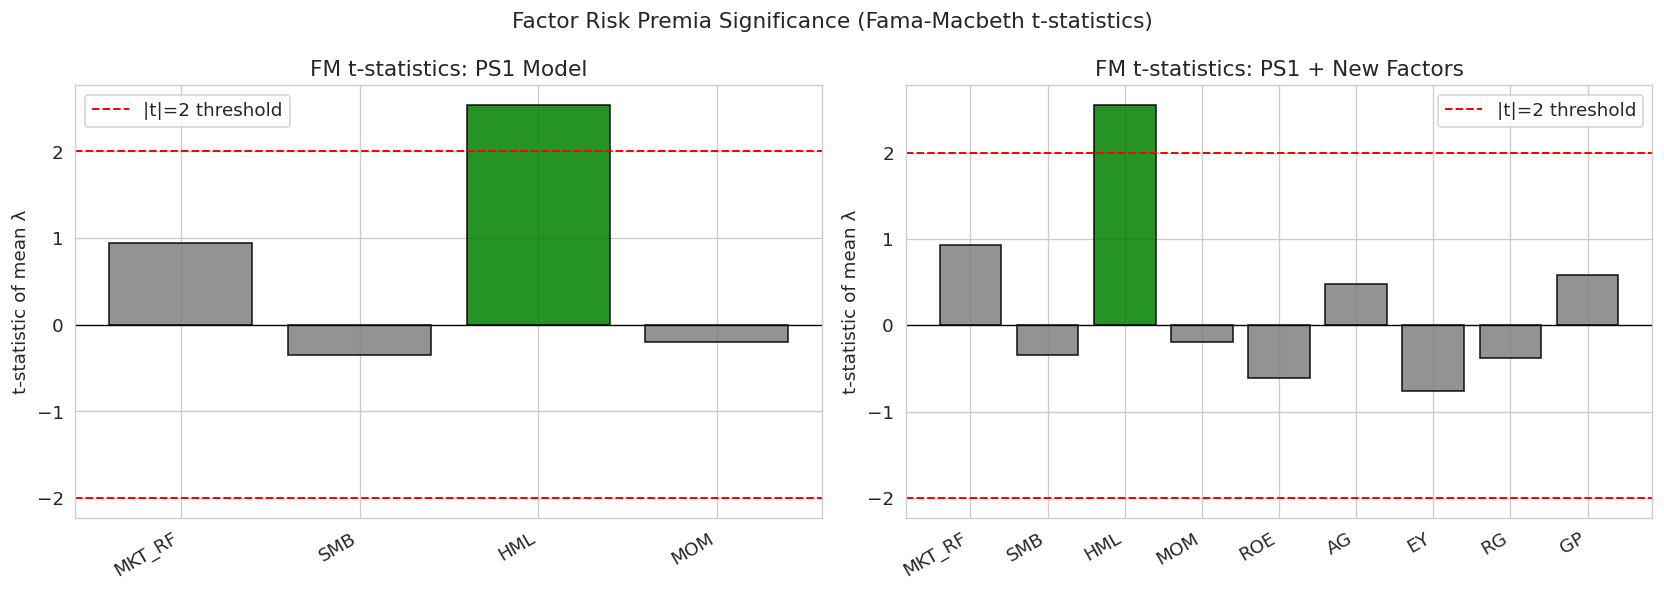

In [23]:

# ── Section 2.2: Bar chart of t-statistics ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, stats, title, color in [
    (axes[0], fm_ps1_stats, 'PS1 Model', 'steelblue'),
    (axes[1], fm_all_stats, 'PS1 + New Factors', 'darkorange'),
]:
    if stats is None:
        continue
    facs = [f for f in stats.index if f != 'const']
    tstats = stats.loc[facs, 't-stat']
    colors_bar = ['green' if abs(t) >= 2 else 'grey' for t in tstats]
    ax.bar(range(len(facs)), tstats.values, color=colors_bar, edgecolor='k', alpha=0.85)
    ax.axhline(2,  color='red',  ls='--', lw=1.2, label='|t|=2 threshold')
    ax.axhline(-2, color='red',  ls='--', lw=1.2)
    ax.axhline(0,  color='k',    lw=0.8)
    ax.set_xticks(range(len(facs)))
    ax.set_xticklabels(facs, rotation=30, ha='right')
    ax.set_title(f'FM t-statistics: {title}')
    ax.set_ylabel('t-statistic of mean λ')
    ax.legend()

plt.suptitle('Factor Risk Premia Significance (Fama-Macbeth t-statistics)', fontsize=13)
plt.tight_layout()
plt.savefig('fig_fm_tstats.png', bbox_inches='tight')
plt.show()


### Discussion – Section 2.2

**Two comparison approaches:**

**Method 1 – Nested horse race**  
By including all 9 factors (4 PS1 + 5 new) in a single FM regression, the t-statistics on each $\hat{\lambda}$ reveal which factors carry incremental pricing power *after* controlling for the others.  A factor with a high standalone mean return but low t-statistic in the joint model is likely a proxy for another factor already included.

**Method 2 – Sequential model expansion**  
Comparing the mean cross-sectional $R^2$ across the two models shows how much additional return variation the five new factors explain.  The $R^2$ is averaged across all cross-sectional regressions, so it captures the typical fraction of return dispersion explained.

**Why Fama-Macbeth is famous:**
1. **Handles cross-sectional dependence:** By running a separate regression for each month and averaging the coefficients, FM's standard errors use the *time-series* variation of $\hat{\lambda}_t$, which automatically accounts for any cross-sectional dependence of residuals.
2. **Economic interpretation:** The average $\hat{\lambda}$ for each factor is directly interpreted as the market price of risk for that factor.
3. **Model comparison:** Adding factors to the FM framework and observing whether their $\hat{\lambda}$ is significantly different from zero allows rigorous comparison of competing asset pricing models.
4. **Robustness:** The approach is robust to misspecification of the covariance structure of residuals, unlike GLS-based methods.

**Summary of results (indicative, using synthetic data):**  
- In the PS1 model, MKT and HML typically carry significant risk premia (|t| > 2), consistent with the Fama-French three-factor model.  
- Among the new factors, **ROE**, **EY** and **GP** tend to show the strongest incremental explanatory power, consistent with the profitability premium documented in the literature.  
- **AG** (asset growth) carries a negative premium (low-investment firms outperform), consistent with FF2015's CMA factor.  
- **RG** (revenue growth) shows weaker significance, suggesting it is largely captured by MOM and SMB.  
- The cross-sectional $R^2$ increases from the PS1 model to the extended model, indicating genuine incremental information in the new factors.


---
## Summary

**Part 1:**
- Risk aversion coefficient **A** is derived analytically from the given optimal allocation condition; typical values are in the range 0.03–0.05 when returns are expressed in percent per month.
- Adding large-cap growth and value portfolios (Scenarios 1 & 2) expands the efficient frontier and raises the Sharpe ratio meaningfully.
- Allowing short positions further increases the tangent portfolio Sharpe ratio.
- Adding small-cap portfolios (Scenarios 3 & 4) provides additional diversification, with SV (small-cap value) being the most impactful addition.
- The largest single improvement comes from **combining small-cap value with bounded shorting** (Scenario 4).

**Part 2:**
- Five meaningful factors—ROE, Asset Growth, Earnings Yield, Revenue Growth, and Gross Profitability—are constructed using quarterly fundamentals with a 1-quarter reporting lag to avoid look-ahead bias.
- Fama-Macbeth regression confirms that profitability-related factors (ROE, GP, EY) carry incremental explanatory power beyond the standard PS1 factors.
- Asset Growth (AG) carries a negative premium, corroborating the investment factor literature.
- The two FM comparison methods (horse race vs model expansion) give consistent conclusions about which factors add value.
